Data streaming simulation

In [1]:
from ir_measures import *
import ir_measures
import ir_datasets
import json

def load_trec_run(run_file_path):
    run = {}
    with open(run_file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            qid = parts[0]
            docid = parts[2]
            score = float(parts[4])
            if qid not in run:
                run[qid] = {}
            run[str(qid)][str(docid)] = float(score)
    return run

def load_qrels(beir_data_name):
    qrels = {}
    datasets = ir_datasets.load(beir_data_name)
    for qrel in datasets.qrels_iter():
        if qrel.query_id not in qrels:
            qrels[qrel.query_id] = {}
        qrels[str(qrel.query_id)][str(qrel.doc_id)] = int(qrel.relevance)
    return qrels

old_model = "sp_tiny"
new_model = "sp_v3"

old_model_queries = {"nDCG@10":[], "old_model_encoded_percentage":[],"new_model_encoded_percentage":[]}
dir = f"/fnwi_fs/ivi/irlab/projects/mllm_yk/jf/lsrbc/results/results_simulation/old_sp_tiny_new_{new_model}_random"
for partition in [100,90, 80, 70, 60, 50, 40, 30, 20, 10, 0]:
    res_partition = 100 - partition
    
    path = f"{dir}/q100_{old_model}_d{partition}_{old_model}_d{res_partition}_{new_model}_msmarco.trec"
    # path = f"{dir}/old_sp_tiny_new_{new_model}/q100_{old_model}_d{partition}_{old_model}_d{res_partition}_{new_model}_msmarco.trec"
    run = load_trec_run(path)
    qrels = load_qrels('beir/msmarco/dev')

    metrics = ir_measures.calc_aggregate([nDCG@10, RR@10], qrels, run)
    print(metrics, f"doc:({old_model}:{partition}%, {new_model}:{res_partition}%)  query:({old_model}:100%)")
    old_model_queries["nDCG@10"].append(metrics[nDCG@10])
    old_model_queries["old_model_encoded_percentage"].append(partition)
    old_model_queries["new_model_encoded_percentage"].append(res_partition)

# print("\n")
new_model_queries = {"nDCG@10":[], "old_model_encoded_percentage":[],"new_model_encoded_percentage":[]}
for partition in [100,90, 80, 70, 60,50, 40, 30, 20, 10, 0]:
    res_partition = 100 - partition
    path = f"{dir}/q100_{new_model}_d{partition}_{old_model}_d{res_partition}_{new_model}_msmarco.trec"
    run = load_trec_run(path)
    qrels = load_qrels('beir/msmarco/dev')

    metrics = ir_measures.calc_aggregate([nDCG@10, RR@10], qrels, run)
    new_model_queries["nDCG@10"].append(metrics[nDCG@10])
    new_model_queries["old_model_encoded_percentage"].append(partition)
    new_model_queries["new_model_encoded_percentage"].append(res_partition)
    print(metrics, f"doc:({old_model}:{partition}%, {new_model}:{res_partition}%)  query:({new_model}:100%)")


{nDCG@10: 0.35755680922156213, RR@10: 0.3039069677536719} doc:(sp_tiny:100%, sp_v3:0%)  query:(sp_tiny:100%)
{nDCG@10: 0.3320345642587356, RR@10: 0.28405495292672855} doc:(sp_tiny:90%, sp_v3:10%)  query:(sp_tiny:100%)
{nDCG@10: 0.3085156628039398, RR@10: 0.2665513144130615} doc:(sp_tiny:80%, sp_v3:20%)  query:(sp_tiny:100%)
{nDCG@10: 0.3295538917429983, RR@10: 0.27944029426479156} doc:(sp_tiny:70%, sp_v3:30%)  query:(sp_tiny:100%)
{nDCG@10: 0.3231777686332005, RR@10: 0.27265355664710805} doc:(sp_tiny:60%, sp_v3:40%)  query:(sp_tiny:100%)
{nDCG@10: 0.3191193874217042, RR@10: 0.2696360917815057} doc:(sp_tiny:50%, sp_v3:50%)  query:(sp_tiny:100%)
{nDCG@10: 0.31438253808015937, RR@10: 0.26446309182698735} doc:(sp_tiny:40%, sp_v3:60%)  query:(sp_tiny:100%)
{nDCG@10: 0.3137042506682368, RR@10: 0.26273309228180164} doc:(sp_tiny:30%, sp_v3:70%)  query:(sp_tiny:100%)
{nDCG@10: 0.31717451402497726, RR@10: 0.2646511575021591} doc:(sp_tiny:20%, sp_v3:80%)  query:(sp_tiny:100%)
{nDCG@10: 0.32597710

rank-based fusion

In [7]:
from ir_measures import *
import ir_measures
import ir_datasets
import json
import json
import ir_datasets
import ir_measures
from ir_measures import *
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def fuse(runs, weights):
    fused_run = {}
    qids = set()
    for run in runs:
        qids.update(run.keys())
    for qid in qids:
        fused_run[qid] = {}
        for run in runs:
            for doc in run[qid]['docs']:
                if doc not in fused_run[qid]:
                    score = 0
                    for temp_run, weight in zip(runs, weights):
                        if doc in temp_run[qid]['docs']:
                            min_score = temp_run[qid]['min_score']
                            max_score = temp_run[qid]['max_score']
                            denominator = max_score - min_score
                            denominator = max(denominator, 1e-9)
                            score += weight * ((temp_run[qid]['docs'][doc] - min_score) / denominator)
                        else:
                            score += 0
                    fused_run[qid][doc] = score
    return fused_run

def convert2fusion(run_dict):
    run = {}
    for qid in run_dict:
        if qid not in run:
            run[qid] = {'docs': {}, 'max_score': None, 'min_score': None}
        scores = list(run_dict[qid].values())
        # print( scores )
        run[qid]['max_score'] = max(scores)
        run[qid]['min_score'] = min(scores)
        for docid, score in run_dict[qid].items():
            run[qid]['docs'][docid] = score
    return run

def rank_fusion(top_old_indices, top_new_indices, k=3, constant=60):
    unique_docs = set(top_old_indices) | set(top_new_indices)
    fused_scores = {doc: 0 for doc in unique_docs}
    
    for rank, doc in enumerate(top_old_indices, 1):
        fused_scores[doc] += 1 / (rank + constant)
    
    for rank, doc in enumerate(top_new_indices, 1):
        fused_scores[doc] += 1 / (rank + constant)
    
    # Sort by fused score descending
    fused_ranked = sorted(fused_scores, key=fused_scores.get, reverse=True)[:k]
    return fused_ranked


def load_trec_run(run_file_path):
    run = {}
    with open(run_file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            qid = parts[0]
            docid = parts[2]
            score = float(parts[4])
            if qid not in run:
                run[qid] = {}
            run[str(qid)][str(docid)] = float(score)
    return run

def load_qrels(beir_data_name):
    qrels = {}
    datasets = ir_datasets.load(beir_data_name)
    for qrel in datasets.qrels_iter():
        if qrel.query_id not in qrels:
            qrels[qrel.query_id] = {}
        qrels[str(qrel.query_id)][str(qrel.doc_id)] = int(qrel.relevance)
    return qrels

old_model = "sp_tiny"
# old_model = "sp_v3_distil"
new_model = "sp_v3"

alpha = 0.5
dir = "/fnwi_fs/ivi/irlab/projects/mllm_yk/jf/lsrbc/results/results_simulation"

old_model_queries = {"nDCG@10":[], "old_model_encoded_percentage":[],"new_model_encoded_percentage":[]}
new_model_queries = {"nDCG@10":[], "old_model_encoded_percentage":[],"new_model_encoded_percentage":[]}
refined_queries = {"nDCG@10":[], "old_model_encoded_percentage":[],"new_model_encoded_percentage":[]}
rank_based_fusion_queries = {"nDCG@10":[], "old_model_encoded_percentage":[],"new_model_encoded_percentage":[]}
for partition in [100, 90, 80, 70, 60, 50, 40, 30, 20, 10, 0]:
    try:
        res_partition = 100 - partition
        
        old_query_path = f"{dir}/old_{old_model}_new_{new_model}/q100_{old_model}_d{partition}_{old_model}_d{res_partition}_{new_model}_msmarco.trec"
        old_query_run = load_trec_run(old_query_path)
        qrels = load_qrels('beir/msmarco/dev')

        old_query_metrics = ir_measures.calc_aggregate([nDCG@10, RR@10], qrels, old_query_run)
        print(old_query_metrics, f"doc:({old_model}:{partition}%, {new_model}:{res_partition}%)  query:({old_model}:100%)")
        old_model_queries["nDCG@10"].append(old_query_metrics[nDCG@10])
        old_model_queries["old_model_encoded_percentage"].append(partition)
        old_model_queries["new_model_encoded_percentage"].append(res_partition)

        new_query_path = f"{dir}/old_sp_tiny_new_{new_model}/q100_{new_model}_d{partition}_{old_model}_d{res_partition}_{new_model}_msmarco.trec"
        new_query_run = load_trec_run(new_query_path)
        qrels = load_qrels('beir/msmarco/dev')

        new_query_metrics = ir_measures.calc_aggregate([nDCG@10, RR@10], qrels, new_query_run)
        print(new_query_metrics, f"doc:({old_model}:{partition}%, {new_model}:{res_partition}%)  query:({new_model}:100%)")
        new_model_queries["nDCG@10"].append(new_query_metrics[nDCG@10])
        new_model_queries["old_model_encoded_percentage"].append(partition)
        new_model_queries["new_model_encoded_percentage"].append(res_partition)

        refined_query_path = f"{dir}/old_sp_tiny_new_{new_model}_random/q100_refined_{new_model}_d{partition}_{old_model}_d{res_partition}_{new_model}_msmarco.trec"
        refined_query_run = load_trec_run(refined_query_path)
        refined_query_metrics = ir_measures.calc_aggregate([nDCG@10, RR@10], qrels, refined_query_run)
        refined_queries["nDCG@10"].append(refined_query_metrics[nDCG@10])
        refined_queries["old_model_encoded_percentage"].append(partition)
        refined_queries["new_model_encoded_percentage"].append(res_partition)
        print(refined_query_metrics, f"doc:({old_model}:{partition}%, {new_model}:{res_partition}%)  query:(refined {new_model}):100%)")

        fusion_run_res = fuse(
            runs=[convert2fusion(new_query_run), 
                convert2fusion(old_query_run)],
            weights=[alpha, (1 - alpha)],
        )

        fusion_run_metrics = ir_measures.calc_aggregate([nDCG@10, RR@10], qrels, fusion_run_res)
        print(fusion_run_metrics, f"doc:({old_model}:{partition}%, {new_model}:{res_partition}%)  query:(fusion)")
        rank_based_fusion_queries["nDCG@10"].append(fusion_run_metrics[nDCG@10])
        rank_based_fusion_queries["old_model_encoded_percentage"].append(partition)
        rank_based_fusion_queries["new_model_encoded_percentage"].append(res_partition)
        print("\n")
    except Exception as e:
        print(f"Error processing partition {partition}: {e}")


{nDCG@10: 0.3567589941101243, RR@10: 0.3031454382134891} doc:(sp_tiny:100%, sp_v3:0%)  query:(sp_tiny:100%)
{nDCG@10: 0.32169195302742015, RR@10: 0.2675585004775539} doc:(sp_tiny:100%, sp_v3:0%)  query:(sp_v3:100%)
{nDCG@10: 0.37356586956934484, RR@10: 0.31764468777004456} doc:(sp_tiny:100%, sp_v3:0%)  query:(refined sp_v3):100%)
{nDCG@10: 0.3612889726596565, RR@10: 0.3049090940100959} doc:(sp_tiny:100%, sp_v3:0%)  query:(fusion)


{nDCG@10: 0.3060802625047039, RR@10: 0.2590768977122835} doc:(sp_tiny:90%, sp_v3:10%)  query:(sp_tiny:100%)
{nDCG@10: 0.4444524778914953, RR@10: 0.4084542570609911} doc:(sp_tiny:90%, sp_v3:10%)  query:(sp_v3:100%)
{nDCG@10: 0.3473566411066184, RR@10: 0.29697292718424395} doc:(sp_tiny:90%, sp_v3:10%)  query:(refined sp_v3):100%)
{nDCG@10: 0.4787008925451676, RR@10: 0.41897911265747995} doc:(sp_tiny:90%, sp_v3:10%)  query:(fusion)


{nDCG@10: 0.30607925848509515, RR@10: 0.25807801200709396} doc:(sp_tiny:80%, sp_v3:20%)  query:(sp_tiny:100%)
{nDCG@10: 0.3882751

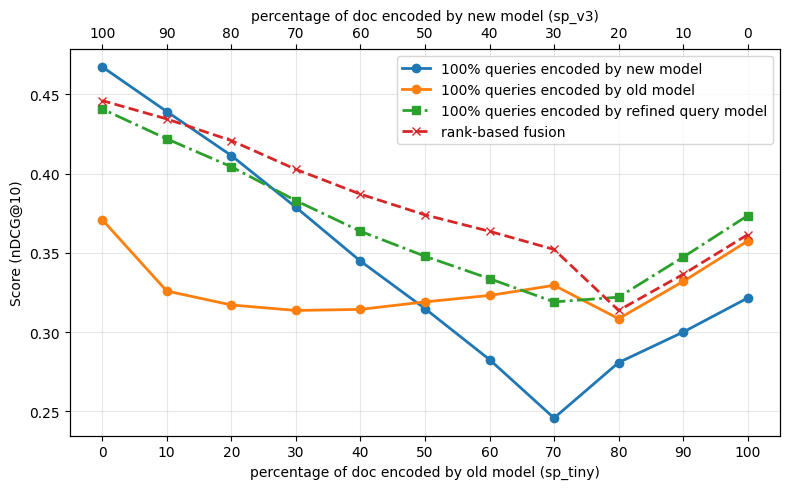

In [3]:
import matplotlib.pyplot as plt

ndcg_new_model, new_model_encoded_percentages, old_model_encoded_percentages = new_model_queries["nDCG@10"], new_model_queries["new_model_encoded_percentage"], new_model_queries["old_model_encoded_percentage"]
ndcg_old_model, _, _  = old_model_queries["nDCG@10"], old_model_queries["old_model_encoded_percentage"], old_model_queries["new_model_encoded_percentage"]
ndcg_rank_based_fusion_model, _, _  = rank_based_fusion_queries["nDCG@10"], rank_based_fusion_queries["old_model_encoded_percentage"], rank_based_fusion_queries["new_model_encoded_percentage"]
ndcg_refined_model, _, _  = refined_queries["nDCG@10"], refined_queries["old_model_encoded_percentage"], refined_queries["new_model_encoded_percentage"]
fig, ax1 = plt.subplots(figsize=(8,5))

# Plot both lines
ax1.plot(old_model_encoded_percentages, ndcg_new_model, marker='o', label='100% queries encoded by new model', linewidth=2)
ax1.plot(old_model_encoded_percentages, ndcg_old_model, marker='o', label='100% queries encoded by old model', linewidth=2)
ax1.plot(old_model_encoded_percentages, ndcg_refined_model, marker='s', label='100% queries encoded by refined query model', linewidth=2, linestyle='-.')
ax1.plot(old_model_encoded_percentages, ndcg_rank_based_fusion_model, marker='x', label='rank-based fusion', linewidth=2, linestyle='--')

# Bottom x-axis
ax1.set_xticks(old_model_encoded_percentages)
ax1.set_xlabel('percentage of doc encoded by old model (sp_tiny)')
ax1.set_ylabel('Score (nDCG@10)')
ax1.grid(True, alpha=0.3)
ax1.legend()
# ax1.set_title('nDCG@10 in relation to percentage of doc encoded by old and new Models')

# Top x-axis
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(old_model_encoded_percentages)
ax2.set_xticklabels(new_model_encoded_percentages)
ax2.set_xlabel('percentage of doc encoded by new model (sp_v3)')
plt.tight_layout()
plt.show()